# Project 

### Asja Basovic


## Sections 1: Algorithms implementation

In [5]:
import json
from typing import List, Dict, Tuple

movies = [
    {"id": 1, "title": "Avatar 2", "duration": 180, "format": "3D", "audience_size": 50, "priority": 1},
    {"id": 2, "title": "Oppenheimer", "duration": 150, "format": "2D", "audience_size": 40, "priority": 2},
    {"id": 3, "title": "Barbie", "duration": 120, "format": "4DX", "audience_size": 30, "priority": 1},
    {"id": 4, "title": "Inception", "duration": 140, "format": "2D", "audience_size": 20, "priority": 3},
    {"id": 5, "title": "Dune", "duration": 160, "format": "3D", "audience_size": 35, "priority": 2},
    {"id": 6, "title": "Interstellar", "duration": 170, "format": "IMAX", "audience_size": 25, "priority": 3},
    {"id": 7, "title": "Testing1", "duration": 200, "format": "IMAX", "audience_size": 0, "priority": 3},
    {"id": 8, "title": "Testing2", "duration": 300, "format": "IMAX", "audience_size": 0, "priority": 3},
    {"id": 9, "title": "Mean Girls", "duration": 100, "format": "IMAX", "audience_size": 25, "priority": 3},
    {"id": 10, "title": "Mean Girls", "duration": 100, "format": "3D", "audience_size": 25, "priority": 3},
    {"id": 11, "title": "Mean Girls", "duration": 100, "format": "2D", "audience_size": 25, "priority": 3},
]

screens = [
    {"id": 1, "capacity": 100, "supported_formats": ["2D", "3D"]},
    {"id": 2, "capacity": 80, "supported_formats": ["4DX", "IMAX"]},
    {"id": 3, "capacity": 120, "supported_formats": ["2D", "3D", "IMAX"]},
    {"id": 4, "capacity": 120, "supported_formats": ["2D"]},
    {"id": 5, "capacity": 150, "supported_formats": ["2D", '4DX']},
]

ticket_prices = {"2D": 10, "3D": 15, "4DX": 20, "IMAX": 18}

In [6]:
def calculate_revenue(movie: Dict, ticket_prices: Dict) -> int:
    return movie["audience_size"] * ticket_prices[movie["format"]]

def is_slot_free(schedule: List[Dict], start_time: int, duration: int) -> bool:
    end_time = start_time + duration
    for scheduled_movie in schedule:
        scheduled_start = scheduled_movie["start_time"]
        scheduled_end = scheduled_movie["end_time"] + 25  # buffer
        if not (end_time <= scheduled_start or start_time >= scheduled_end):
            return False
    return True

def dp_scheduler(movies: List[Dict], screens: List[Dict], ticket_prices: Dict, days: int = 14) -> Dict:
    schedule = {f"day_{day}": {f"screen_{screen['id']}": [] for screen in screens} for day in range(1, days + 1)}
    unscheduled_movie_ids = set(m["id"] for m in movies)

    for day in range(1, days + 1):
        for screen in screens:
            screen_schedule = schedule[f"day_{day}"][f"screen_{screen['id']}"]
            remaining_time = 720

            must_schedule = [
                m for m in movies
                if m["id"] in unscheduled_movie_ids and m["format"] in screen["supported_formats"]
            ]
            must_schedule.sort(key=lambda m: (-m["priority"], -calculate_revenue(m, ticket_prices)))

            for movie in must_schedule:
                duration_with_buffer = movie["duration"] + 25
                for t in range(0, 721 - duration_with_buffer):
                    if is_slot_free(screen_schedule, t, movie["duration"]):
                        screen_schedule.append({
                            "start_time": t,
                            "end_time": t + movie["duration"],
                            "movie": movie["title"],
                            "revenue": calculate_revenue(movie, ticket_prices),
                            'must': 1
                        })
                        unscheduled_movie_ids.discard(movie["id"])
                        remaining_time -= duration_with_buffer
                        break

            dp = [{"revenue": 0, "movies": []} for _ in range(721)]
            for t in range(721):
                for movie in [m for m in movies if m["format"] in screen["supported_formats"]]:
                    duration_with_buffer = movie["duration"] + 25
                    if t >= duration_with_buffer:
                        revenue = calculate_revenue(movie, ticket_prices)
                        if dp[t - duration_with_buffer]["revenue"] + revenue > dp[t]["revenue"]:
                            if is_slot_free(screen_schedule, t - duration_with_buffer, movie["duration"]):
                                dp[t] = {
                                    "revenue": dp[t - duration_with_buffer]["revenue"] + revenue,
                                    "movies": dp[t - duration_with_buffer]["movies"] + [movie]
                                }

            for movie in dp[720]["movies"]:
                for t in range(0, 721 - movie["duration"]):
                    if is_slot_free(screen_schedule, t, movie["duration"]):
                        screen_schedule.append({
                            "start_time": t,
                            "end_time": t + movie["duration"],
                            "movie": movie["title"],
                            "revenue": calculate_revenue(movie, ticket_prices),
                            'must': 0
                        })
                        break
    return schedule

def greedy_scheduler(movies: List[Dict], screens: List[Dict], ticket_prices: Dict, days: int = 14) -> Dict:
    schedule = {f"day_{day}": {f"screen_{screen['id']}": [] for screen in screens} for day in range(1, days + 1)}
    unscheduled_movie_ids = set(m["id"] for m in movies)

    for day in range(1, days + 1):
        for screen in screens:
            screen_schedule = schedule[f"day_{day}"][f"screen_{screen['id']}"]
            remaining_time = 720

            must_schedule = [
                m for m in movies
                if m["id"] in unscheduled_movie_ids and m["format"] in screen["supported_formats"]
            ]
            must_schedule.sort(key=lambda m: (calculate_revenue(m, ticket_prices), -m["priority"]), reverse=True)

            for movie in must_schedule:
                duration_with_buffer = movie["duration"] + 25
                if remaining_time >= duration_with_buffer:
                    start_time = 720 - remaining_time
                    if is_slot_free(screen_schedule, start_time, movie["duration"]):
                        screen_schedule.append({
                            "start_time": start_time,
                            "end_time": start_time + movie["duration"],
                            "movie": movie["title"],
                            "revenue": calculate_revenue(movie, ticket_prices),
                            "must": 1
                        })
                        remaining_time -= duration_with_buffer
                        unscheduled_movie_ids.discard(movie["id"])

            compatible_movies = sorted(
                [m for m in movies if m["format"] in screen["supported_formats"]],
                key=lambda m: (calculate_revenue(m, ticket_prices), -m["priority"]),
                reverse=True
            )

            for movie in compatible_movies:
                duration_with_buffer = movie["duration"] + 25
                if remaining_time >= duration_with_buffer:
                    start_time = 720 - remaining_time
                    if is_slot_free(screen_schedule, start_time, movie["duration"]):
                        screen_schedule.append({
                            "start_time": start_time,
                            "end_time": start_time + movie["duration"],
                            "movie": movie["title"],
                            "revenue": calculate_revenue(movie, ticket_prices),
                            "must": 0
                        })
                        remaining_time -= duration_with_buffer

    return schedule


In [7]:
def print_schedule(schedule: Dict):
    print(json.dumps(schedule, indent=2))

def compare_algorithms():
    print("=== DP/Knapsack Scheduler ===")
    dp_schedule = dp_scheduler(movies, screens, ticket_prices, days=2)
    print_schedule(dp_schedule)

    print("\n=== Greedy Scheduler ===")
    greedy_schedule = greedy_scheduler(movies, screens, ticket_prices, days=2)
    print_schedule(greedy_schedule)

if __name__ == "__main__":
    compare_algorithms()


=== DP/Knapsack Scheduler ===
{
  "day_1": {
    "screen_1": [
      {
        "start_time": 0,
        "end_time": 100,
        "movie": "Mean Girls",
        "revenue": 375,
        "must": 1
      },
      {
        "start_time": 125,
        "end_time": 225,
        "movie": "Mean Girls",
        "revenue": 250,
        "must": 1
      },
      {
        "start_time": 250,
        "end_time": 390,
        "movie": "Inception",
        "revenue": 200,
        "must": 1
      },
      {
        "start_time": 415,
        "end_time": 575,
        "movie": "Dune",
        "revenue": 525,
        "must": 1
      }
    ],
    "screen_2": [
      {
        "start_time": 0,
        "end_time": 170,
        "movie": "Interstellar",
        "revenue": 450,
        "must": 1
      },
      {
        "start_time": 195,
        "end_time": 295,
        "movie": "Mean Girls",
        "revenue": 450,
        "must": 1
      },
      {
        "start_time": 320,
        "end_time": 520,
        "m

## Section 2: Empirical analysis

In [1]:
import time
import tracemalloc
import matplotlib.pyplot as plt
import random

def generate_movies(num):
    formats = ["2D", "3D", "4DX", "IMAX"]
    return [
        {
            "id": i,
            "title": f"Movie {i}",
            "duration": random.choice([90, 120, 150, 180]),
            "format": random.choice(formats),
            "audience_size": random.randint(10, 100),
            "priority": random.randint(1, 3)
        }
        for i in range(1, num + 1)
    ]

def generate_screens(num):
    formats = ["2D", "3D", "4DX", "IMAX"]
    return [
        {
            "id": i,
            "capacity": random.randint(50, 150),
            "supported_formats": random.sample(formats, random.randint(1, 3))
        }
        for i in range(1, num + 1)
    ]


def measure_performance(algorithm, movies, screens, days):
    tracemalloc.start()
    start_time = time.time()
    schedule = algorithm(movies, screens, ticket_prices, days)
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return (end_time - start_time), (peak / 1024 / 1024)  

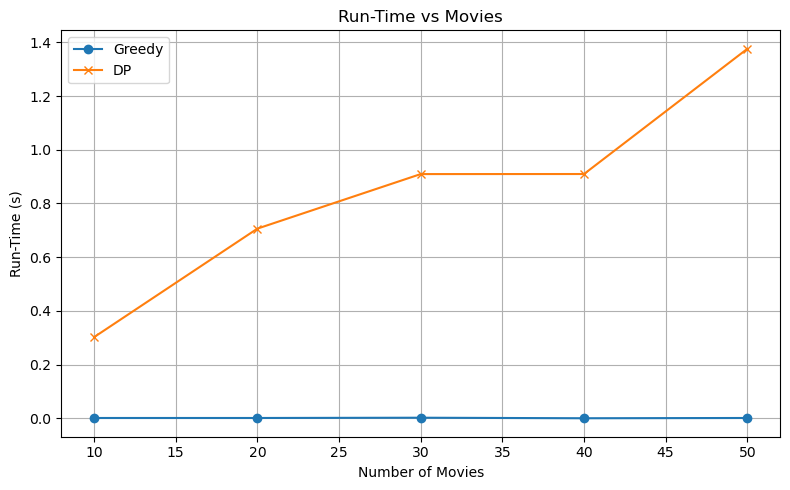

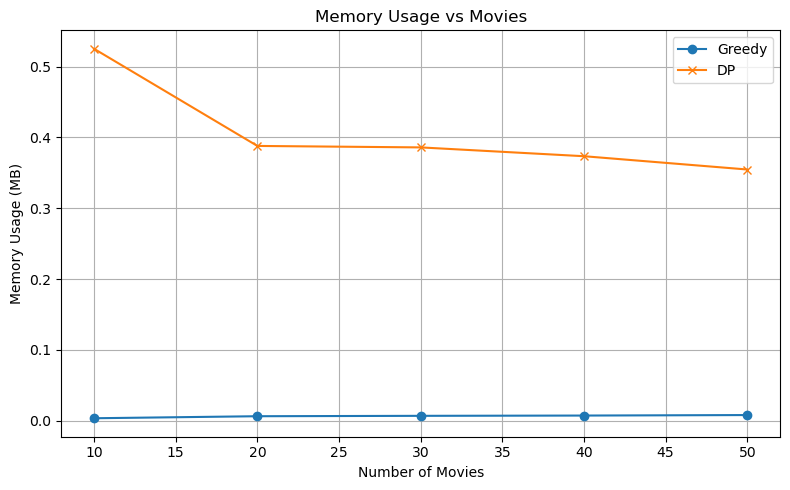

In [12]:
movie_counts = [10, 20, 30, 40, 50]
screen_counts = [2, 3, 4, 5, 6]
day_counts = [1, 3, 5, 7, 10]

results = {
    "greedy": {"time": [], "memory": []},
    "dp": {"time": [], "memory": []}
}

for m in movie_counts:
    movies = generate_movies(m)
    screens = generate_screens(3)
    days = 3

    t_g, mem_g = measure_performance(greedy_scheduler, movies, screens, days)
    t_dp, mem_dp = measure_performance(dp_scheduler, movies, screens, days)

    results["greedy"]["time"].append(t_g)
    results["greedy"]["memory"].append(mem_g)
    results["dp"]["time"].append(t_dp)
    results["dp"]["memory"].append(mem_dp)

def plot_metric(x_vals, greedy_vals, dp_vals, xlabel, ylabel, title):
    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, greedy_vals, label="Greedy", marker='o')
    plt.plot(x_vals, dp_vals, label="DP", marker='x')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_metric(movie_counts, results["greedy"]["time"], results["dp"]["time"], 
            xlabel="Number of Movies", ylabel="Run-Time (s)", title="Run-Time vs Movies")

plot_metric(movie_counts, results["greedy"]["memory"], results["dp"]["memory"], 
            xlabel="Number of Movies", ylabel="Memory Usage (MB)", title="Memory Usage vs Movies")


In [72]:
  results["greedy"]["time"]

[0.0,
 0.002001523971557617,
 0.0009996891021728516,
 0.0009996891021728516,
 0.0009968280792236328]

In [73]:
  results["dp"]["time"]

[0.42386841773986816,
 0.6665558815002441,
 0.7325360774993896,
 0.6016983985900879,
 1.3657350540161133]

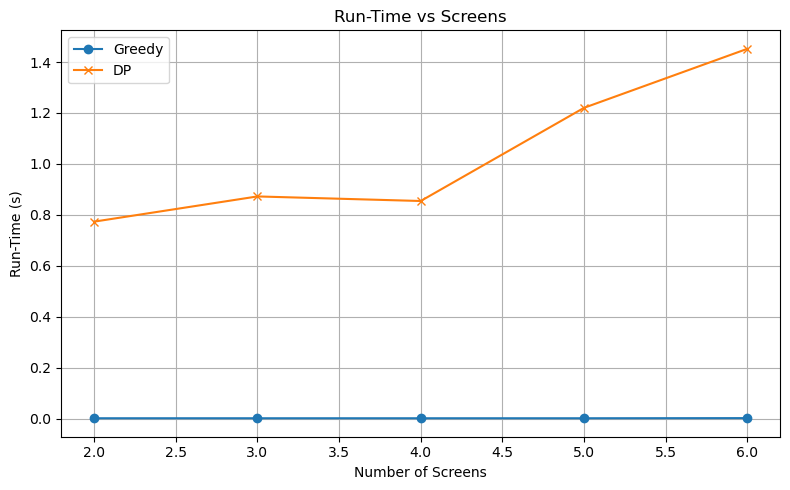

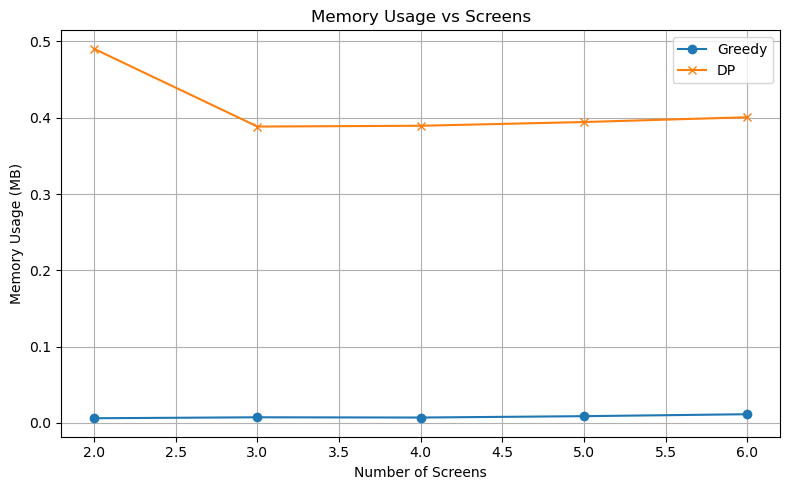

In [13]:
screen_counts = [2, 3, 4, 5, 6]
results_screens = {
    "greedy": {"time": [], "memory": []},
    "dp": {"time": [], "memory": []}
}

for s in screen_counts:
    movies = generate_movies(30) 
    screens = generate_screens(s)
    days = 3  

    t_g, mem_g = measure_performance(greedy_scheduler, movies, screens, days)
    t_dp, mem_dp = measure_performance(dp_scheduler, movies, screens, days)

    results_screens["greedy"]["time"].append(t_g)
    results_screens["greedy"]["memory"].append(mem_g)
    results_screens["dp"]["time"].append(t_dp)
    results_screens["dp"]["memory"].append(mem_dp)

plot_metric(screen_counts, results_screens["greedy"]["time"], results_screens["dp"]["time"],
            xlabel="Number of Screens", ylabel="Run-Time (s)", title="Run-Time vs Screens")

plot_metric(screen_counts, results_screens["greedy"]["memory"], results_screens["dp"]["memory"],
            xlabel="Number of Screens", ylabel="Memory Usage (MB)", title="Memory Usage vs Screens")


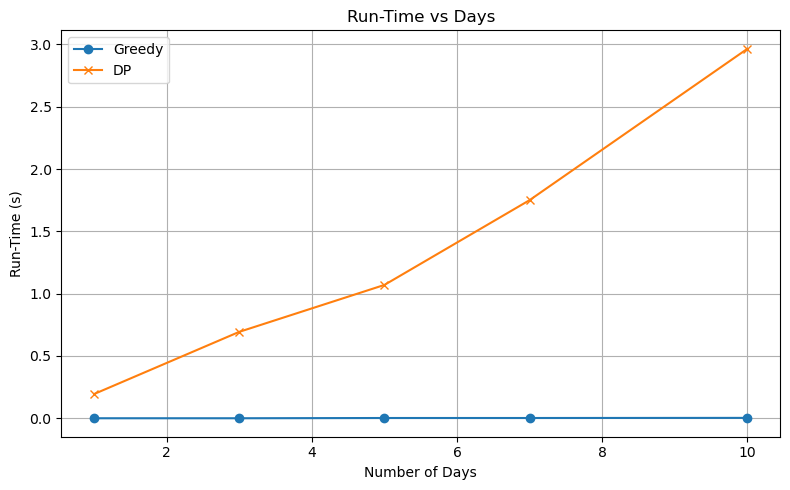

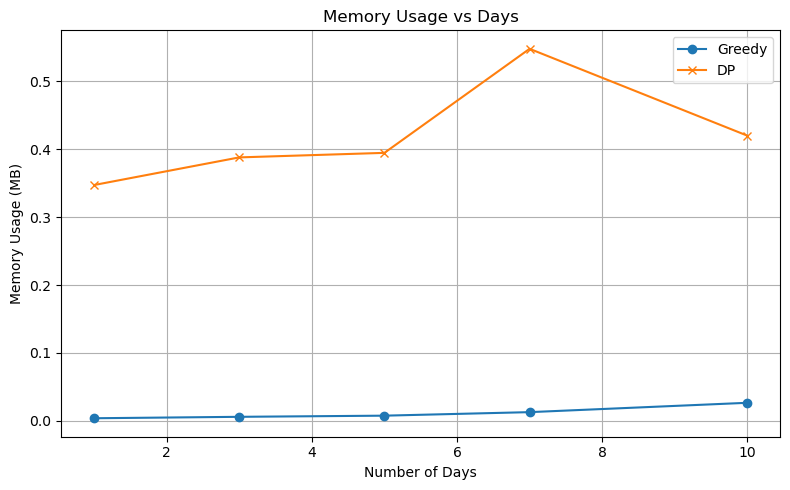

In [81]:
day_counts = [1, 3, 5, 7, 10]
results_days = {
    "greedy": {"time": [], "memory": []},
    "dp": {"time": [], "memory": []}
}

for d in day_counts:
    movies = generate_movies(30)  
    screens = generate_screens(3)  
    days = d

    t_g, mem_g = measure_performance(greedy_scheduler, movies, screens, days)
    t_dp, mem_dp = measure_performance(dp_scheduler, movies, screens, days)

    results_days["greedy"]["time"].append(t_g)
    results_days["greedy"]["memory"].append(mem_g)
    results_days["dp"]["time"].append(t_dp)
    results_days["dp"]["memory"].append(mem_dp)

plot_metric(day_counts, results_days["greedy"]["time"], results_days["dp"]["time"],
            xlabel="Number of Days", ylabel="Run-Time (s)", title="Run-Time vs Days")

plot_metric(day_counts, results_days["greedy"]["memory"], results_days["dp"]["memory"],
            xlabel="Number of Days", ylabel="Memory Usage (MB)", title="Memory Usage vs Days")
